In [2]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [3]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords
import string
from sklearn.utils import shuffle
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import torch
import wandb
print("Done")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Done


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ag-news-classification-dataset


In [5]:
train = pd.read_csv('/kaggle/input/ag-news-classification-dataset/train.csv')
test = pd.read_csv('/kaggle/input/ag-news-classification-dataset/test.csv')
train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [6]:
train.rename(columns={'Class Index': 'labels'}, inplace=True)
test.rename(columns={'Class Index': 'labels'}, inplace=True)

In [7]:
train['labels'].unique()

array([3, 4, 2, 1])

In [8]:
train['labels'] = train['labels']-1
test['labels'] = test['labels']-1

In [9]:
train['labels'].unique()

array([2, 3, 1, 0])

In [10]:
train['text'] = train['Title'] + train['Description']
test['text'] = test['Title'] + test['Description']

In [11]:
train.drop(['Title', 'Description'], axis=1, inplace=True)
test.drop(['Title', 'Description'], axis=1, inplace=True)

In [12]:
print('Train')
print(train.isna().sum())
print('Test')
print(test.isna().sum())

Train
labels    0
text      0
dtype: int64
Test
labels    0
text      0
dtype: int64


In [13]:
print('Train')
print(train.duplicated().sum())
print('Test')
print(test.duplicated().sum())

Train
0
Test
0


In [14]:
def remove_stop_words(txt):
    stop_words = stopwords.words('english')
    return ' '.join([x for x in txt.split() if x not in stop_words])

def remove_punc(txt):
    text_non_punct = "".join([char for char in txt if char not in string.punctuation])
    return text_non_punct

In [15]:
train['text'] = train['text'].apply(lambda x: x.lower())
train['text'] = train['text'].apply(lambda x: remove_stop_words(x))
train['text'] = train['text'].apply(lambda x: remove_punc(x))
train = shuffle(train, random_state=42).reset_index(drop=True)

In [16]:
test['text'] = test['text'].apply(lambda x: x.lower())
test['text'] = test['text'].apply(lambda x: remove_stop_words(x))
test['text'] = test['text'].apply(lambda x: remove_punc(x))
test = shuffle(test, random_state=42).reset_index(drop=True)

In [17]:
train.head()

,labels,text
0,2,bbc set major shakeup claims newspaperlondon ...
1,2,marsh averts cash crunchembattled insurance br...
2,1,jeter yankees look take control apap derek je...
3,3,flying sun safetywhen genesis capsule comes ba...
4,2,stocks seen flat nortel oil weigh new york reu...


In [18]:
test.head()

,labels,text
0,1,fan v fan manchester citytottenham hotspurthis...
1,0,paris tourists search key da vinci code reuter...
2,3,net firms tax voipthe spanishamerican war temp...
3,3,dependent species risk extinctionthe global ex...
4,3,eds charter member siebel bpo alliance newsfac...


In [19]:
training = Dataset.from_pandas(train)
testing = Dataset.from_pandas(test)

In [20]:
tokenizer = AutoTokenizer.from_pretrained('albert-base-v2')

def tokenization(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True)

train_dataset = training.map(tokenization, batched=True)
test_dataset = testing.map(tokenization, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [21]:
train_dataset.set_format('torch')
test_dataset.set_format('torch')

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
model = model = AutoModelForSequenceClassification.from_pretrained("albert-base-v2", num_labels=4)
model.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AlbertForSequenceClassification(
  (albert): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertSdpaAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=

In [49]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    logging_dir='./logs',
    logging_steps=50,
    fp16=True if torch.cuda.is_available() else False
)

In [50]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.234000,0.238250,0.922632,0.924501,0.922632,0.922155
2,0.196100,0.204165,0.933947,0.934276,0.933947,0.933810
3,0.104800,0.212459,0.936974,0.937116,0.936974,0.936971


TrainOutput(global_step=11250, training_loss=0.19622499304877386, metrics={'train_runtime': 11548.6728, 'train_samples_per_second': 31.172, 'train_steps_per_second': 0.974, 'total_flos': 8605017538560000.0, 'train_loss': 0.19622499304877386, 'epoch': 3.0})

In [52]:
results = trainer.evaluate()
results

{'eval_loss': 0.21245884895324707,
 'eval_accuracy': 0.9369736842105263,
 'eval_precision': 0.9371157194780904,
 'eval_recall': 0.9369736842105263,
 'eval_f1': 0.9369707275113562,
 'eval_runtime': 90.849,
 'eval_samples_per_second': 83.655,
 'eval_steps_per_second': 2.62,
 'epoch': 3.0}

In [53]:
model.save_pretrained("./news_classification_albert_model")
tokenizer.save_pretrained("./news_classification_albert_model")

('./news_classification_albert_model/tokenizer_config.json',
 './news_classification_albert_model/special_tokens_map.json',
 './news_classification_albert_model/spiece.model',
 './news_classification_albert_model/added_tokens.json',
 './news_classification_albert_model/tokenizer.json')

In [54]:
log_history = trainer.state.log_history

train_loss = [log["loss"] for log in log_history if "loss" in log]
eval_loss = [log["eval_loss"] for log in log_history if "eval_loss" in log]
accuracy = [log["eval_accuracy"] for log in log_history if "eval_accuracy" in log]

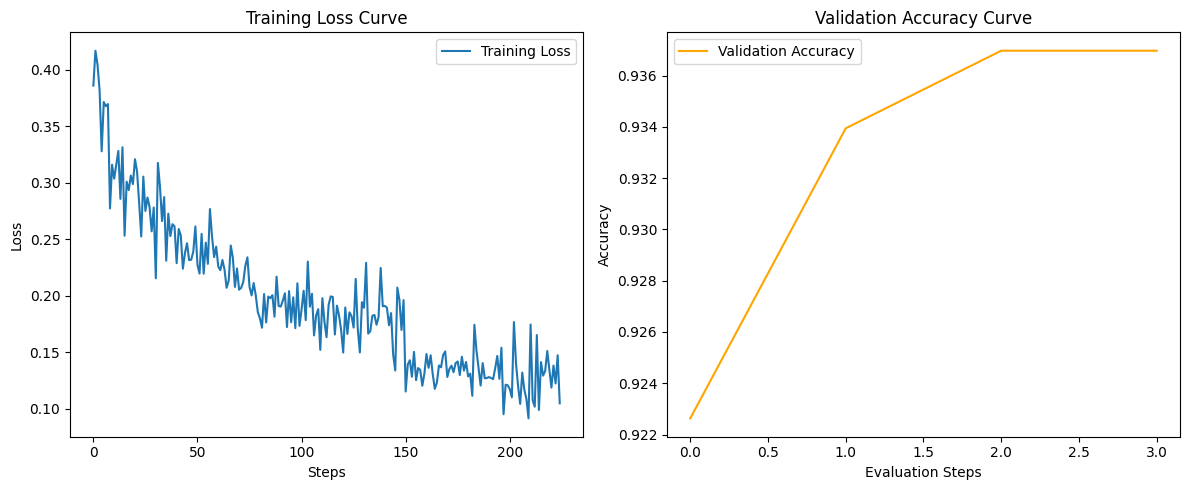

In [55]:
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(train_loss, label="Training Loss")
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy
plt.subplot(1,2,2)
plt.plot(accuracy, label="Validation Accuracy", color='orange')
plt.title("Validation Accuracy Curve")
plt.xlabel("Evaluation Steps")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("news_classification_albert_model")
tokenizer = AutoTokenizer.from_pretrained("news_classification_albert_model")

In [57]:
user_input = input("Enter a news article: ")
labels = ["World", "Sports", "Business", "Sci/Tech"]
inputs = tokenizer(user_input, return_tensors="pt", truncation=True, padding=True)
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=1).item()
    print(f"Predicted Class: {labels[predicted_class_id]}")

Enter a news article: Real Madrid is the best team.
Predicted Class: Sports
